# Australian Budget Program Profiles

Explores `programs.db` — Portfolio → Agency → Outcome → Program spending
parsed from Portfolio Budget Statements, 2017-18 through 2025-26 (Budget
editions only; MYEFO not included).

Every chart below uses **estimated actual** figures (the mid-year, "here's
what we now think we'll actually spend" number published in the *following*
year's Budget for the prior financial year) — the most reliable figure PBS
documents publish, since forward estimates get revised repeatedly but an
estimated actual is close to the final outturn.

**Before trusting a rollup**, read [`KNOWN_GAPS.md`](KNOWN_GAPS.md) in this
folder — in particular: Defence's core operational programs are not
captured (bespoke table format), and `agency`/`portfolio` names drift across
years since they're parsed from filenames/folders, not a canonical
registry. This notebook normalises the worst of that drift for its
portfolio-level chart (see the `PORTFOLIO_KEYWORDS` cell) but you should
treat agency/portfolio names as fuzzy, and `program_name` as the one
reasonably stable join key across years.


In [1]:
import re
import sqlite3
import difflib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DB_PATH = "programs.db"

# --- Palette (validated categorical order -- see dataviz skill) -----------
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
               "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
OTHER_GRAY = "#9c9b95"
TEXT_PRIMARY = "#0b0b0b"
TEXT_SECONDARY = "#52514e"
GRID_COLOR = "#e3e2dd"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID_COLOR,
    "axes.labelcolor": TEXT_SECONDARY,
    "text.color": TEXT_PRIMARY,
    "xtick.color": TEXT_SECONDARY,
    "ytick.color": TEXT_SECONDARY,
    "axes.grid": True,
    "grid.color": GRID_COLOR,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})


def money_axis(ax, divisor=1_000_000, suffix="bn"):
    """Format a $'000-denominated axis in $bn / $m for readability.

    amount_thousands is in $'000, i.e. actual dollars = amount_thousands *
    1,000. So $bn = amount_thousands / 1e6, and $m = amount_thousands / 1e3.
    """
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"${v/divisor:,.0f}{suffix}"))


## Load estimated-actual data

In [2]:
con = sqlite3.connect(DB_PATH)
df = pd.read_sql_query(
    """SELECT edition, budget_year, portfolio, agency, outcome_number,
              outcome_description, program_number, program_name,
              fiscal_year, amount_thousands
       FROM program_expenses
       WHERE estimate_type = 'estimated_actual' """,
    con)
con.close()

# `portfolio` is a raw folder name and drifts across years (e.g. "Health" vs
# "2021-22 PBS Health" vs "2022-23 PBS Health"). PORTFOLIO_KEYWORDS below
# does lightweight keyword-based normalisation to group those back together.
# It's a heuristic, not a registry -- inspect `portfolio_key` if a
# portfolio's line looks wrong later on, and extend the keyword list as
# needed.
PORTFOLIO_KEYWORDS = [
    ("Health", ["health"]),
    ("Education", ["education"]),
    ("Social Services", ["social services"]),
    ("Defence", ["defence"]),
    ("Veterans' Affairs", ["veteran"]),
    ("Treasury", ["treasury"]),
    ("Industry / Science / Resources", ["industry"]),
    ("Infrastructure / Transport", ["infrastructure"]),
    ("Agriculture", ["agricultur"]),
    ("Foreign Affairs & Trade", ["foreign affairs"]),
    ("Attorney-General's", ["attorney"]),
    ("Home Affairs / Immigration", ["home affairs", "immigration", "border protection"]),
    ("Prime Minister & Cabinet", ["prime minister", "pm&c", "pmc"]),
    ("Employment / Workplace Relations", ["employment"]),
    ("Climate Change / Energy / Environment / Water", ["climate change", "environment", "energy and water", "dccceew", "dcceew"]),
    ("Communications & the Arts", ["communications"]),
    ("Finance", ["finance"]),
    ("Parliamentary Departments", ["parliament"]),
]


def portfolio_key(raw):
    low = str(raw).lower()
    for label, keywords in PORTFOLIO_KEYWORDS:
        if any(k in low for k in keywords):
            return label
    return raw  # left as-is: inspect these if they matter to your analysis


df["portfolio_key"] = df["portfolio"].map(portfolio_key)

# 2022 is the one year with two Budgets: the pre-election March 2022-23
# Budget and the post-election October 2022-23 Budget. Both report FY21-22
# as their "estimated actual" -- and unlike every other cross-edition
# overlap, this one can't be resolved by matching on portfolio/agency
# labels, because the two editions used *very* different naming
# conventions for the same real agency in the same year (e.g. Education
# was filed as "Dept of Education, Skills and Employment" in March but
# "OCT EDU" in October) -- no keyword-based normalisation reliably catches
# every such pair. March is kept outright (it's at least comparably
# complete -- 1,839 rows / 15 portfolios vs October's 1,873 rows / 16 --
# and is the preferred edition here) and October's FY21-22 rows are
# dropped before any label-based logic runs.
df = df[~((df.edition == "2022-23 October Budget") & (df.fiscal_year == "2021-22"))]

# `agency` is a raw filename-derived label and isn't stable across editions
# for the *same* real agency (e.g. the ATO's file is labelled "Australian
# Taxation Office" in the 2022-23 March Budget but "ATO October" in the
# 2022-23 October Budget) -- deduping on it directly would let both
# editions' rows through as if they were different agencies, double-
# counting. `program_name` is far more stable, so dedup on
# (portfolio, program name, program number, fiscal year) instead, which
# sidesteps agency-label drift entirely. This is a secondary safety net
# for any other cross-edition overlap beyond the March/October 2022-23
# pair already handled above.
#
# NOTE this can't safely be loosened to drop portfolio_key from the key
# entirely: several small agencies leave program_name as a literal
# "(Insert program name)" template placeholder, and different real
# agencies collide on that placeholder + program_number + fiscal_year --
# deduping without a portfolio/agency qualifier would silently drop their
# (distinct, real) figures.
df["fy_start"] = df["fiscal_year"].str.slice(0, 4).astype(int)
df["budget_year_start"] = df["budget_year"].str.slice(0, 4).astype(int)
df["gap"] = df["budget_year_start"] - df["fy_start"]
df = (df.sort_values("gap")
        .drop_duplicates(subset=["portfolio_key", "program_name", "program_number", "fiscal_year"],
                          keep="first"))

# Outcomes get renumbered on machinery-of-government changes (see the
# Health note further down: old Outcome 4 became the new Outcome 2 in the
# 2021-22 Budget) -- so `outcome_number` alone is not a safe grouping key
# across years, the same way `program_name` (not `program_number`) is the
# right key at the program level. `outcome_description` is the stable
# identity; group and plot by that instead, falling back to the bare
# number only for the agencies whose source sheets never state a
# description at all (e.g. Health -- see coverage check via
# `df.outcome_description.isna().mean()`).
has_desc = df["outcome_description"].notna() & (df["outcome_description"].str.strip() != "")
df["outcome_label"] = df["outcome_description"].where(
    has_desc, "Outcome " + df["outcome_number"].astype(str) + " (no description in source)")

print(f"{len(df):,} estimated-actual rows | FY {df.fiscal_year.min()} - {df.fiscal_year.max()}")
print(f"{df.agency.nunique()} distinct agency labels | {df.program_name.nunique()} distinct program names")
print(f"{has_desc.mean():.0%} of rows have a source outcome description; the rest fall back to 'Outcome N'")
df.head()


3,334 estimated-actual rows | FY 2016-17 - 2024-25
699 distinct agency labels | 662 distinct program names
62% of rows have a source outcome description; the rest fall back to 'Outcome N'


,edition,budget_year,portfolio,agency,outcome_number,outcome_description,program_number,program_name,fiscal_year,amount_thousands,portfolio_key,fy_start,budget_year_start,gap,outcome_label
0,2017-18 Budget,2017-18,Agriculture and Water Resources,AFMA,1,Ecologically sustainable and economically effi...,1.1,Australian Fisheries Management Authority,2016-17,45263,Agriculture,2016,2017,1,Ecologically sustainable and economically effi...
2226,2022-23 March Budget,2022-23,2022-23 PBS Veterans' Affairs,Department of Veterans Affairs,1,None,1.3,Assistance to Defence Widow/ers and Dependants,2021-22,1137454,Veterans' Affairs,2021,2022,1,Outcome 1 (no description in source)
2227,2022-23 March Budget,2022-23,2022-23 PBS Veterans' Affairs,Department of Veterans Affairs,1,None,1.4,Assistance and Other Compensation for Veterans...,2021-22,19983,Veterans' Affairs,2021,2022,1,Outcome 1 (no description in source)
2228,2022-23 March Budget,2022-23,2022-23 PBS Veterans' Affairs,Department of Veterans Affairs,1,None,1.5,Veterans' Children Education Scheme,2021-22,17224,Veterans' Affairs,2021,2022,1,Outcome 1 (no description in source)
2229,2022-23 March Budget,2022-23,2022-23 PBS Veterans' Affairs,Department of Veterans Affairs,1,None,1.6,Military Rehabilitation and Compensation Acts ...,2021-22,1874133,Veterans' Affairs,2021,2022,1,Outcome 1 (no description in source)


## Whole-of-government trend

Total estimated-actual spend across every captured program, by fiscal year.
This is a sanity check more than an analysis: it should climb roughly in
line with known nominal budget growth. Because Defence's core programs
aren't captured (see `KNOWN_GAPS.md`), **this trend understates total
Commonwealth spending** and its shape should not be read as "the" budget
trend.


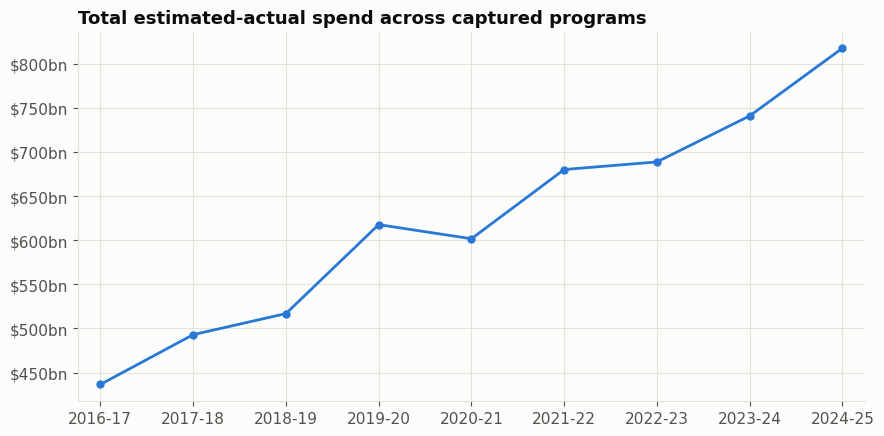

In [3]:
by_fy = df.groupby("fiscal_year")["amount_thousands"].sum().sort_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(by_fy.index, by_fy.values, color=CATEGORICAL[0], linewidth=2,
        marker="o", markersize=5)
money_axis(ax)
ax.set_title("Total estimated-actual spend across captured programs", loc="left",
             fontsize=13, color=TEXT_PRIMARY, fontweight="bold")
ax.set_xlabel("")
ax.margins(x=0.03)
plt.setp(ax.get_xticklabels(), rotation=0)
fig.tight_layout()
plt.show()


## Portfolio-level profiles over time

Using the `portfolio_key` normalisation computed when the data was loaded
above.


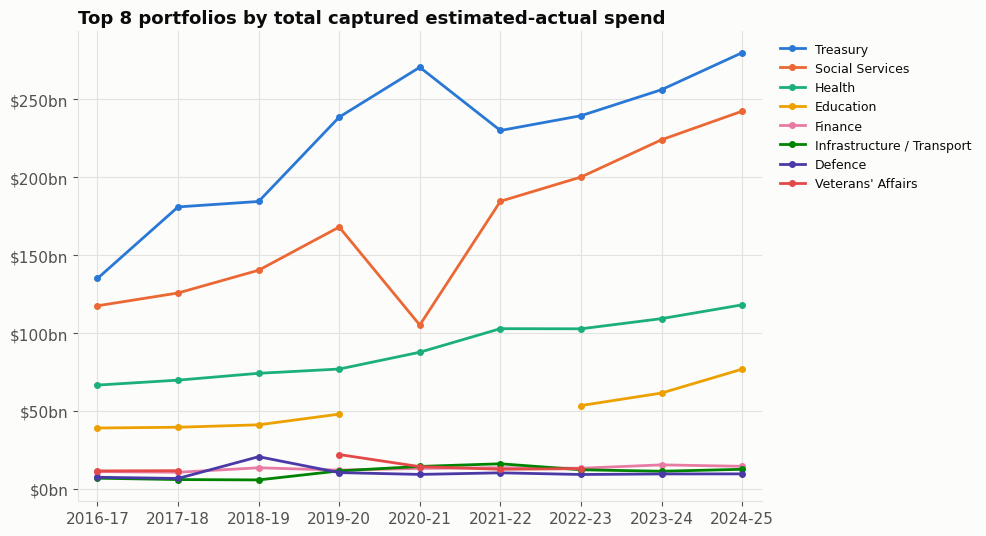

In [4]:
top_portfolios = (df.groupby("portfolio_key")["amount_thousands"].sum()
                     .sort_values(ascending=False).head(8).index.tolist())

pivot = (df[df.portfolio_key.isin(top_portfolios)]
           .groupby(["fiscal_year", "portfolio_key"])["amount_thousands"].sum()
           .unstack("portfolio_key")
           .reindex(columns=top_portfolios)  # keep legend order == rank order
           .sort_index())

fig, ax = plt.subplots(figsize=(10, 5.5))
for i, col in enumerate(pivot.columns):
    ax.plot(pivot.index, pivot[col], color=CATEGORICAL[i % len(CATEGORICAL)],
            linewidth=2, marker="o", markersize=4, label=col)
money_axis(ax)
ax.set_title("Top 8 portfolios by total captured estimated-actual spend", loc="left",
             fontsize=13, color=TEXT_PRIMARY, fontweight="bold")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False, fontsize=9)
ax.margins(x=0.03)
fig.tight_layout()
plt.show()


## Outcome profile for a given agency

The core view: within one agency, how has spend on each *outcome* moved
over time? Two ways to select an agency's rows:

- `agency_frame(patterns)` -- loose, substring-based, good for a first look.
- `agency_frame_exact(labels)` -- exact-match against a curated label list.

**Loose substring matching is a trap here.** For example `"education"` also
matches `"Education, Skills and Employment ACARA"` -- a *different legal
entity* (a small statutory authority) that happens to share the portfolio's
name prefix in some years' filenames. Summing its Outcome 1 in with the
core department's Outcome 1 silently conflates two agencies. The three
worked examples below use `agency_frame_exact` with label lists verified
against every edition via `agency_labels()` (further down) for exactly this
reason -- copy that pattern for your own agencies rather than reaching for
a loose substring.


In [5]:
def agency_frame(patterns):
    """Rows whose agency matches any of the given substrings (case-insensitive).

    Quick and loose -- verify with agency_labels() first, since a substring
    can accidentally pull in an unrelated statutory sub-agency. Prefer
    agency_frame_exact for anything you're going to draw conclusions from.
    """
    mask = df["agency"].str.contains("|".join(patterns), case=False, na=False, regex=True)
    return df[mask]


def agency_frame_exact(labels):
    """Rows whose agency exactly matches one of the given labels (case-insensitive)."""
    wanted = {l.lower() for l in labels}
    return df[df["agency"].str.lower().isin(wanted)]


def agency_labels(substring):
    """Every raw agency label containing `substring` -- use this to build an
    agency_frame_exact() list before trusting a chart."""
    return sorted(df.loc[df.agency.str.contains(substring, case=False, na=False), "agency"].unique())


def short_label(text, n=55):
    text = str(text)
    return text if len(text) <= n else text[:n].rstrip() + "…"


FALLBACK_LABEL_RE = re.compile(r"^Outcome \d+ \(no description in source\)$")


def cluster_labels(labels, threshold=0.90):
    """Map each label to a canonical form, merging near-duplicates.

    Outcome descriptions carry the odd typo ("environments" / "enivironments")
    or minor rewording between editions without the outcome actually
    changing -- an exact-string group-by would split those into spurious
    extra series. Greedily cluster by difflib similarity instead: each new
    label joins the first existing cluster it's >=threshold similar to
    (representative = that cluster's first-seen member), else starts a new
    one. 0.90 was picked by checking it against this dataset's known cases:
    it merges a same-outcome typo (ratio 0.998) and reworded scope (0.93-
    0.94), while keeping a genuine outcome split separate (0.72) -- see the
    Education example in the notebook.

    Fallback labels ("Outcome 1 (no description in source)", "Outcome 2
    (...)") are excluded from fuzzy matching and never merged with
    anything, including each other: they differ from one another only in
    the outcome number, which is exactly the one character fuzzy matching
    would treat as noise -- clustering them would silently sum an agency's
    genuinely distinct, merely undescribed outcomes into one line (this is
    what happens to Health below, which has zero description coverage).
    """
    reps = []  # first-seen representative string per cluster
    mapping = {}
    for label in dict.fromkeys(labels):  # unique, first-seen order
        if FALLBACK_LABEL_RE.match(str(label)):
            mapping[label] = label
            continue
        match = next((r for r in reps
                      if not FALLBACK_LABEL_RE.match(r)
                      and difflib.SequenceMatcher(None, label, r).ratio() >= threshold), None)
        if match is None:
            reps.append(label)
            match = label
        mapping[label] = match
    return mapping


def resolve_outcome_labels(sub):
    """Return sub with `outcome_label` backfilled and fuzzy-clustered.

    Backfill: some editions omit the outcome description in years where
    others include it (e.g. DVA only states it from 2024-25 onward) --
    within this one agency, if a given outcome_number has exactly ONE
    distinct real description anywhere in its history, use it for every row
    of that number, so a single isolated year doesn't fork off as its own
    "real label" line instead of continuing the outcome's existing
    fallback-labelled line.

    This deliberately does NOT backfill when a number has *multiple*
    distinct real descriptions (e.g. Health's outcome 2 was "Health Access
    and Support Services" pre-2021 and is unrelated new content "Individual
    Health Benefits" post-2021, both under number 2) -- picking the more
    frequent one and applying it everywhere would silently relabel the
    other era's genuinely different outcome as this one. Ambiguous cases
    are left as-is (real description where the source stated one, fallback
    "Outcome N" label where it didn't) rather than guessed.

    Then fuzzy-cluster via cluster_labels to merge near-duplicate wording
    (typos, minor rewording) while keeping genuinely different outcomes,
    including different fallback numbers, separate.
    """
    sub = sub.copy()
    has_desc = sub["outcome_description"].notna() & (sub["outcome_description"].str.strip() != "")
    if has_desc.any():
        desc_counts = sub.loc[has_desc].groupby("outcome_number")["outcome_description"].nunique()
        unambiguous_numbers = desc_counts[desc_counts == 1].index
        desc_lookup = (sub.loc[has_desc & sub["outcome_number"].isin(unambiguous_numbers)]
                          .groupby("outcome_number")["outcome_description"].first())
        backfilled = sub["outcome_number"].map(desc_lookup)
        sub["outcome_label"] = backfilled.combine_first(sub["outcome_label"])
    sub["outcome_label"] = sub["outcome_label"].map(cluster_labels(sub["outcome_label"]))
    return sub


def plot_outcome_profile(sub, title, ax=None):
    """sub: a pre-filtered frame, e.g. from agency_frame_exact().

    Grouped by `outcome_label` (the outcome's own description text, via
    resolve_outcome_labels), not `outcome_number` -- a number can mean
    something different after a machinery-of-government change (see the
    Health note below), so two same-numbered-but-differently-described
    outcomes must plot as separate lines rather than being silently summed
    together.
    """
    if sub.empty:
        print("No rows in `sub`")
        return
    sub = resolve_outcome_labels(sub)

    totals = sub.groupby("outcome_label")["amount_thousands"].sum().sort_values(ascending=False)
    top_labels = totals.head(8).index.tolist()
    sub["outcome_group"] = sub["outcome_label"].where(sub["outcome_label"].isin(top_labels), "Other")

    pivot = (sub.groupby(["fiscal_year", "outcome_group"])["amount_thousands"].sum()
                .unstack("outcome_group").sort_index())
    order = top_labels + (["Other"] if "Other" in pivot.columns else [])
    pivot = pivot.reindex(columns=order)

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(9, 4.8))
    colors = CATEGORICAL[:len(top_labels)] + ([OTHER_GRAY] if "Other" in pivot.columns else [])
    for color, col in zip(colors, pivot.columns):
        ax.plot(pivot.index, pivot[col], color=color,
                linewidth=2, marker="o", markersize=4, label=short_label(col))
    money_axis(ax, divisor=1_000, suffix="m")
    ax.set_title(title, loc="left", fontsize=13, color=TEXT_PRIMARY, fontweight="bold")
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False, fontsize=9)
    ax.margins(x=0.03)
    # Outcome descriptions are long even truncated, so the legend eats a lot
    # of the figure width -- rotate the year labels so 9 of them still fit
    # legibly in what's left (tight_layout alone doesn't budget space for a
    # bbox_to_anchor legend outside the axes, so without this the labels
    # compress and overlap).
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    if own_fig:
        fig.tight_layout()
        plt.show()
    return pivot


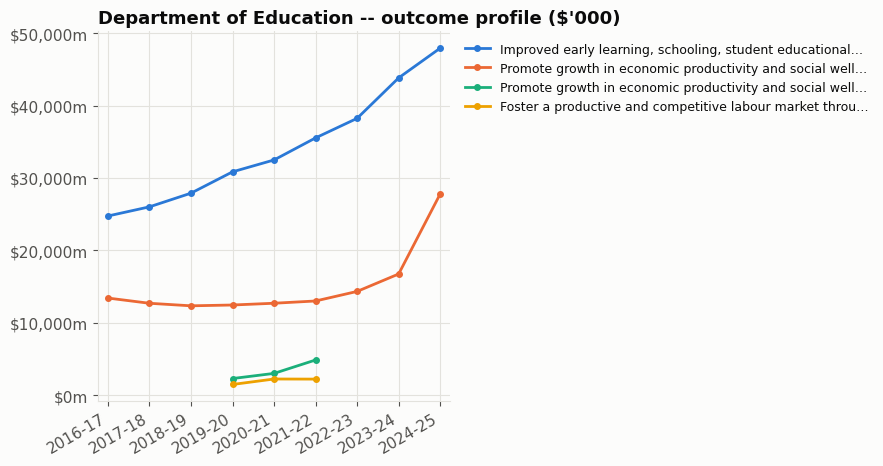

In [6]:
# Verified against every edition 2017-18 through 2025-26 via agency_labels():
# the core department has been filed under six different names, and one
# (2021-22's "Education, Skills and Employment DESE") shares a prefix with
# five statutory sub-agencies (ACARA, AITSL, ARC, TEQSA, ASQA) that must be
# excluded -- hence the exact-match list rather than a substring.
EDUCATION_LABELS = [
    "Education and Training", "DET", "Department of Education and Training clean",
    "ESE", "Education, Skills and Employment DESE",
    "Dept of Education, Skills and Employment", "OCT EDU", "Education",
]
_ = plot_outcome_profile(
    agency_frame_exact(EDUCATION_LABELS),
    "Department of Education -- outcome profile ($'000)")


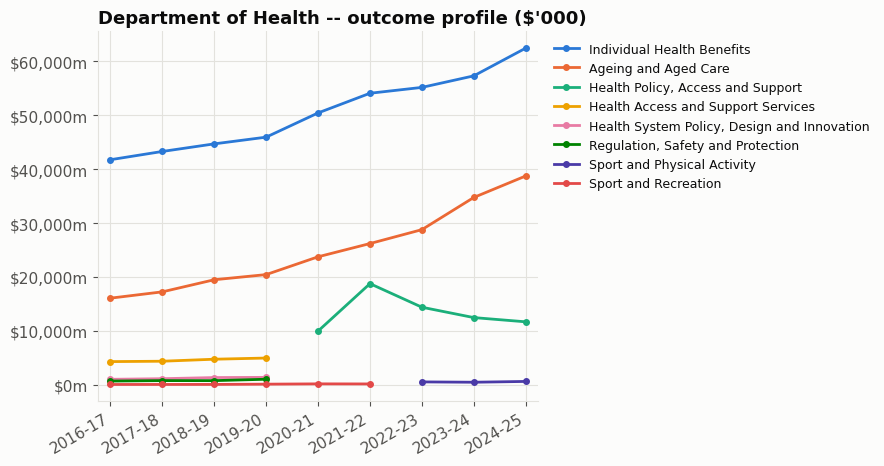

In [7]:
HEALTH_LABELS = [
    "Health", "Health clean", "Department of Health",
    "For Finance Health October", "PS Health",
]
_ = plot_outcome_profile(
    agency_frame_exact(HEALTH_LABELS),
    "Department of Health -- outcome profile ($'000)")


**Outcome 4 collapsing to ~$0 right as Outcome 2 jumps up in 2020-21 is a
real event, not a bug.** The 2021-22 Budget completely renumbered Health's
outcomes: old Outcome 4 ("Medical Benefits", "Pharmaceutical Benefits", ...)
became the new Outcome 2; old Outcome 6 ("Aged Care Services", "Aged Care
Quality") became the new Outcome 3; three old outcomes (1, 2, 5) were merged
into the new Outcome 1; old Outcome 3 ("Sport and Recreation") became the
new Outcome 4 -- confirmed by comparing the program-to-outcome mapping
either side of the transition.

This is exactly the case `plot_outcome_profile` groups by `outcome_label`
(the description text) rather than the raw number to guard against -- but
**Health's source sheets never state an outcome description at all** (see
the "% of rows have a source outcome description" print-out when the data
was loaded), so this chart still falls back to the bare number and still
shows the jump. For an agency that *does* carry a description (Education,
DVA, ...) the same renumbering would instead show as the old label's line
ending and a new label's line beginning -- still a visible discontinuity,
but one you can attribute to a specific outcome by name rather than
mistaking for a number that quietly changed meaning.


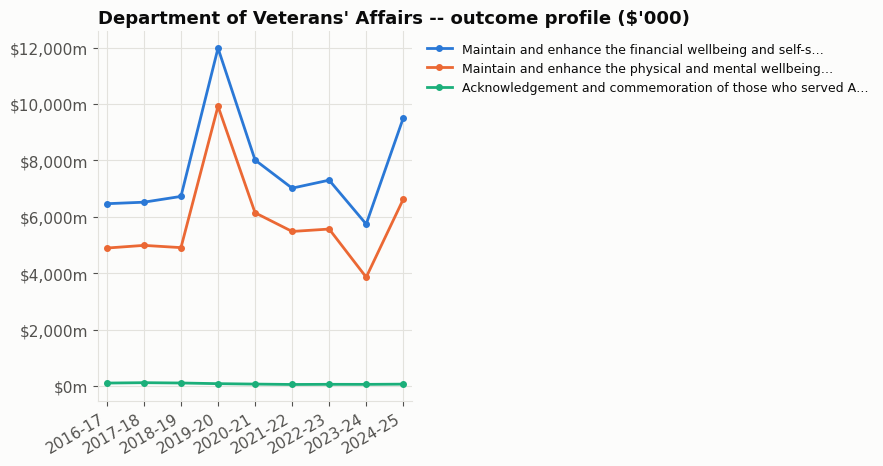

In [8]:
DVA_LABELS = [
    "DVA", "DVA Clean", "Veterans' Affairs",
    "Department of Veterans Affairs", "OCT DVA",
]
_ = plot_outcome_profile(
    agency_frame_exact(DVA_LABELS),
    "Department of Veterans' Affairs -- outcome profile ($'000)")


## Program-level drill-down within one outcome

One level deeper: within a chosen agency + outcome, how has each *program*
moved over time? Capped at the top 8 programs by total spend (the palette's
categorical limit); everything else folds into "Other" rather than
generating an unreadable rainbow.

Note the "Child Care Subsidy" line starting from zero in 2020-21: it's a
preview of the "same function, different name" problem mentioned in the
notebook intro -- the program was called "Support for the Child Care
System" / "Child Care Benefit" / "Child Care Rebate" in earlier years
before being consolidated and renamed. `program_name` alone won't stitch
that history together; it's the starting point for that investigation, not
a finished answer to it.


In [9]:
def plot_program_profile(sub, outcome_contains, title):
    """sub: a pre-filtered frame, e.g. from agency_frame_exact().

    outcome_contains: a case-insensitive substring to match against
    outcome_label -- deliberately *not* outcome_number, for the same
    reason plot_outcome_profile doesn't group by it: a number can mean a
    different outcome after a machinery-of-government change, so filtering
    on the raw number risks quietly mixing two unrelated outcomes'
    programs together across such a boundary.
    """
    sub = resolve_outcome_labels(sub)
    sub = sub[sub["outcome_label"].str.contains(outcome_contains, case=False, na=False)]
    if sub.empty:
        print(f"No rows with outcome_label containing {outcome_contains!r}")
        return

    totals = sub.groupby("program_name")["amount_thousands"].sum().sort_values(ascending=False)
    top_programs = totals.head(8).index.tolist()
    sub["program_group"] = sub["program_name"].where(
        sub["program_name"].isin(top_programs), "Other")

    pivot = (sub.groupby(["fiscal_year", "program_group"])["amount_thousands"].sum()
                .unstack("program_group").sort_index())
    order = top_programs + (["Other"] if "Other" in pivot.columns else [])
    pivot = pivot.reindex(columns=order)

    fig, ax = plt.subplots(figsize=(10, 5.5))
    colors = CATEGORICAL[:len(top_programs)] + ([OTHER_GRAY] if "Other" in pivot.columns else [])
    for color, col in zip(colors, pivot.columns):
        ax.plot(pivot.index, pivot[col], color=color, linewidth=2,
                marker="o", markersize=4, label=short_label(col, 40))
    money_axis(ax, divisor=1_000, suffix="m")
    ax.set_title(title, loc="left", fontsize=13, color=TEXT_PRIMARY, fontweight="bold")
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False, fontsize=8)
    ax.margins(x=0.03)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    fig.tight_layout()
    plt.show()
    return pivot


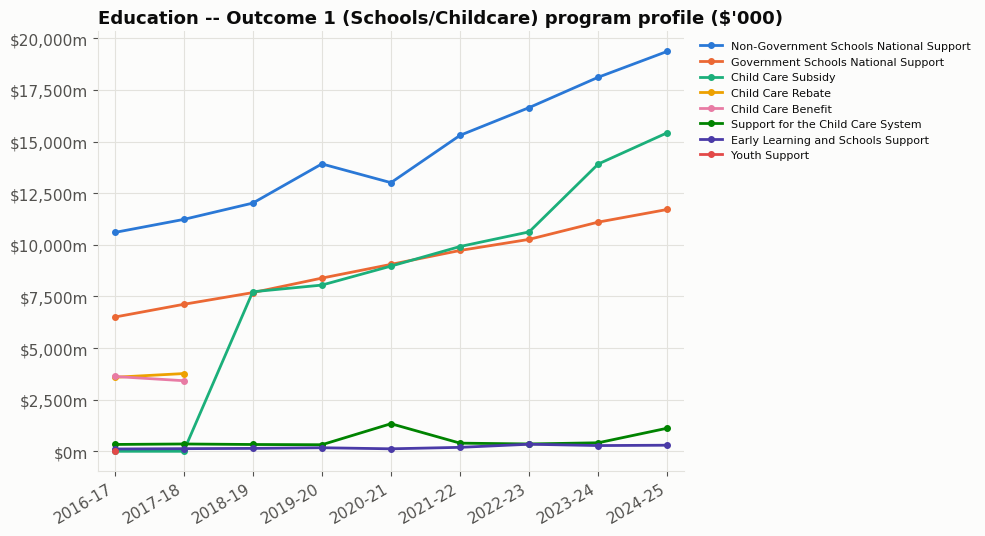

In [10]:
_ = plot_program_profile(
    agency_frame_exact(EDUCATION_LABELS), outcome_contains="early learning",
    title="Education -- Outcome 1 (Schools/Childcare) program profile ($'000)")


## Looking up an agency's exact `agency` labels

Since `agency` drifts across years, use this to find every raw label a
given agency appears under, then pass the relevant ones to
`agency_frame_exact(...)` -- **don't** skip straight to a loose substring
(see the warning above).


In [11]:
agency_labels("health")


['Aust Commission on Safety and Quality in Health Care',
 'Australian Digital Health Agency',
 'Australian Institute of Health and Welfare',
 'Department of Health',
 'Health',
 'Health clean',
 'National Health Funding Body',
 'National Health and Medical Research Council',
 'National Mental Health Commission',
 'PS Health']

## Where to go next

- Swap in your own `patterns` / `outcome_number` in the drill-down cells
  above to profile any agency in the database.
- `df` is the full estimated-actual table in memory -- group/filter it
  directly for anything not covered by the two helper functions.
- The parked "same function, different name" investigation (programs that
  were renamed but serve the same purpose across years) hasn't been
  started yet -- `program_name` plus the outcome/program-number history in
  `df` is the starting point for that.
